In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import savgol_filter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import AutoMinorLocator
import warnings
import re


In [2]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.latex.preamble': r'\usepackage{sfmath} \renewcommand{\familydefault}{\sfdefault} \normalfont',
})

styles = {
    r'G = 0.05, $\sigma_e$ = 0.05': {'c': '#e41a1c', 'm': 'o', 'ls': '-',  'lw': 3.0, 'z': 2},
    r'G = 0.05, $\sigma_e$ = 0.40': {'c': '#377eb8', 'm': 's', 'ls': '--', 'lw': 2.5, 'z': 5},
    r'G = 0.30, $\sigma_e$ = 0.05': {'c': '#4daf4a', 'm': 'D', 'ls': '-.', 'lw': 3.0, 'z': 3},
    r'G = 0.30, $\sigma_e$ = 0.40': {'c': '#ff7f00', 'm': '^', 'ls': '-',  'lw': 4.5, 'z': 1},
}

h_times = {
    r'G = 0.05, $\sigma_e$ = 0.05': [1, 5, 200, 5000],
    r'G = 0.05, $\sigma_e$ = 0.40': [1, 5, 200, 5000],
    r'G = 0.30, $\sigma_e$ = 0.05': [1, 5, 200, 5000],
    r'G = 0.30, $\sigma_e$ = 0.40': [1, 5, 200, 5000],
}

In [3]:
def load_and_average(directory, col_name, num_files=50):
    all_values = {}
    if not os.path.exists(directory):
        print(f"Fail: {directory}")
        return None, None
    
    files_found = 0
    for i in range(1, num_files + 1):
        path = os.path.join(directory, f'evolution_global{i}.dat')
        if os.path.exists(path):
            files_found += 1
            data = pd.read_csv(path, sep='\s+')
            data.columns = [c.strip() for c in data.columns]
            for t, val in zip(data['Generation'], data[col_name]):
                all_values.setdefault(t, []).append(val)
    
    if files_found == 0: return None, None
    
    times = np.array(sorted(all_values.keys()))
    means = np.array([np.mean(all_values[t]) for t in times])
    return times, means

def smooth_data(data, window=11, poly=2):
    if len(data) < window:
        new_window = len(data) if len(data) % 2 != 0 else len(data) - 1
        if new_window <= poly: return data
        return savgol_filter(data, new_window, poly, mode='nearest')
    return savgol_filter(data, window, poly, mode='nearest')

def format_ax(a, major_size=36, is_int=False):
    a.tick_params(which='both', direction='in', top=True, right=True)
    a.tick_params(which='major', length=12, width=1.5, labelsize=major_size)
    a.tick_params(which='minor', length=6, width=1.2)
    a.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    a.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    fmt = r'$\mathsf{%d}$' if is_int else r'$\mathsf{%g}$'
    a.xaxis.set_major_formatter(ticker.FormatStrFormatter(fmt))
    a.yaxis.set_major_formatter(ticker.FormatStrFormatter(fmt))



In [4]:
# Directories
homo_dirs = {
    r'G = 0.05, $\sigma_e$ = 0.05': 'code/DATA/sigma30/heterogeneous/G5/',
    r'G = 0.05, $\sigma_e$ = 0.40': 'code/DATA/sigma30/heterogeneous/G30/',
    r'G = 0.30, $\sigma_e$ = 0.05': 'code/DATA/sigma30/homogeneous/G5/',
    r'G = 0.30, $\sigma_e$ = 0.40': 'code/DATA/sigma30/homogeneous/G30/',
}
hetero_dirs = {
    r'G = 0.05, $\sigma_e$ = 0.05': 'DATA/heterogeneous/G5sigma5/',
    r'G = 0.05, $\sigma_e$ = 0.40': 'DATA/heterogeneous/G5sigma40/',
    r'G = 0.30, $\sigma_e$ = 0.05': 'DATA/heterogeneous/G30sigma5/',
    r'G = 0.30, $\sigma_e$ = 0.40': 'DATA/heterogeneous/G30sigma40/',
}

dirs = homo_dirs  # change for hetero_dirs when you want it

##code/DATA/sigma30/heterogeneous/G5/

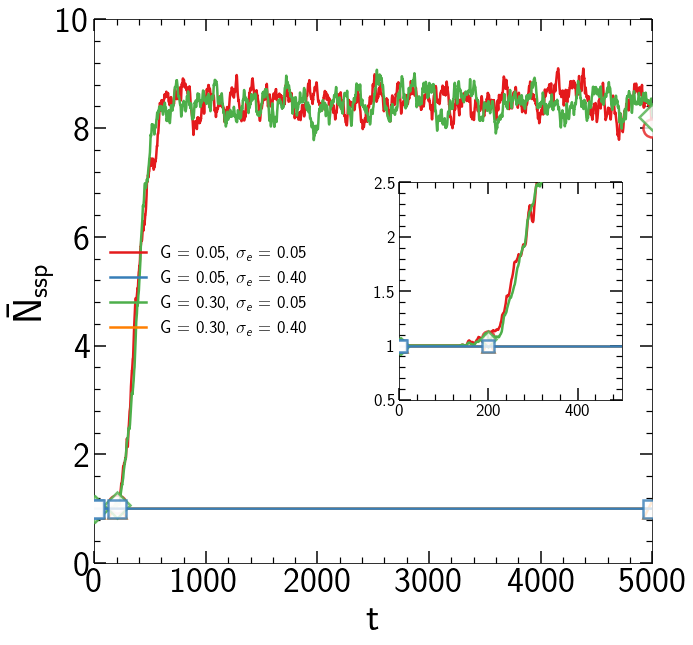

In [5]:
# --- PLOT 1: Species Count (Nspp) ---
fig, ax = plt.subplots(figsize=(10, 10))
ax_ins = inset_axes(ax, width="40%", height="40%", loc='center right', borderpad=3)

for label, path in dirs.items():
    t, m = load_and_average(path, 'SpeciesCount')
    if t is None: continue
    
    cfg = styles[label]
    y_smooth = smooth_data(m, window=11)
    
    for a in [ax, ax_ins]:
        a.plot(t, y_smooth, lw=2.5, color=cfg['c'], label=label if a==ax else "", zorder=cfg['z'])
        
        m_times = [tp for tp in h_times[label] if tp in t]
        m_vals = [m[np.where(t==tp)[0][0]] for tp in m_times]
        a.plot(m_times, m_vals, ls='None', marker=cfg['m'], ms=18 if a==ax else 12, 
               mfc='white', mec=cfg['c'], mew=2.5, alpha=0.8, zorder=cfg['z']+1)

format_ax(ax)
format_ax(ax_ins, major_size=18)
ax.set_xlabel(r'$\mathsf{t}$', fontsize=40); ax.set_ylabel(r'$\mathsf{\bar{N}_{\mathrm{ssp}}}$', fontsize=40)
ax.set_xlim(0, 5000); ax.set_ylim(0, 10)
ax_ins.set_xlim(0, 500); ax_ins.set_ylim(0.5, 2.5)
ax.legend(fontsize=18, loc='center left', frameon=False)
plt.savefig("Nssp.pdf", format = 'pdf')
plt.show()



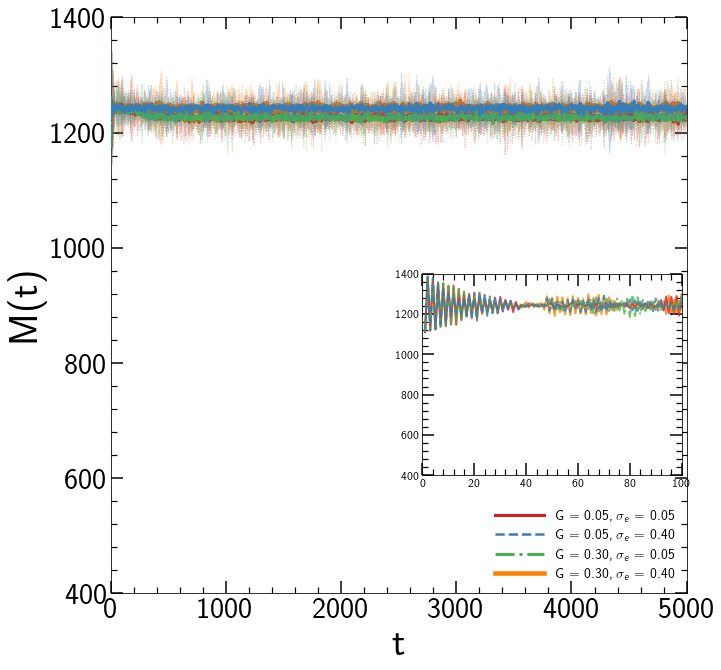

In [6]:
# --- PLOT 2: Population Size (M(t)) ---
fig, ax = plt.subplots(figsize=(10, 10))
axins = inset_axes(ax, width="45%", height="35%", loc='center right', 
                   bbox_to_anchor=(0.0, -0.12, 1, 1), bbox_transform=ax.transAxes)

for label, path in dirs.items():
    t, m = load_and_average(path, 'PopulationSize', num_files=100)
    if t is None: continue
    
    cfg = styles[label]
    
    ax.plot(t, m, color=cfg['c'], linestyle=':', linewidth=1.0, alpha=0.3, zorder=cfg['z'])
    
    m_smooth = smooth_data(m, window=15)
    ax.plot(t, m_smooth, color=cfg['c'], linestyle=cfg['ls'], 
            linewidth=cfg['lw'], label=label, zorder=cfg['z'])
    
    axins.plot(t, m, color=cfg['c'], linestyle=cfg['ls'], linewidth=2.0, alpha=0.8, zorder=cfg['z'])

for a in [ax, axins]:
    format_ax(a, major_size=30 if a == ax else 12, is_int=True)

ax.set_xlabel(r'$\mathsf{t}$', fontsize=40); ax.set_ylabel(r'$\mathsf{M(t)}$', fontsize=40)
ax.set_xlim(0, 5000); ax.set_ylim(400, 1400)
axins.set_xlim(0, 100); axins.set_ylim(400, 1400)
ax.legend(fontsize=14, loc='lower right', frameon=False, handlelength=3.5)
plt.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.15)
plt.savefig("M.pdf", format = 'pdf')

plt.show()

# Analyze parameters 

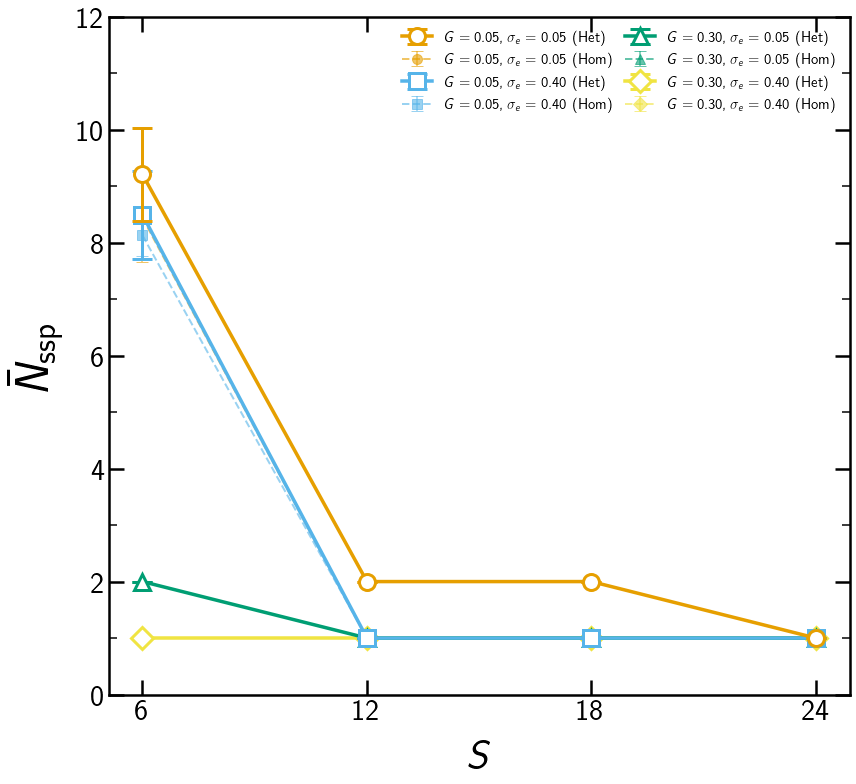

In [7]:
warnings.simplefilter(action='ignore', category=FutureWarning)

plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.latex.preamble': r'\usepackage{sfmath} \renewcommand{\familydefault}{\sfdefault} \normalfont',
})

base_path = "code/DATA/radiusS/"
modes = ["heterogeneous", "homogeneous"]
file_prefix = "evolution_global"
coluna_analise = 1  
fracao_janela_temporal = 0.05 

results = []

for mode in modes:
    folder_path = os.path.join(base_path, mode)
    if not os.path.exists(folder_path): continue
    
    for root, dirs, files in os.walk(folder_path):
        replica_files = [f for f in files if f.startswith(file_prefix) and f.endswith(".dat")]
        
        if replica_files:
            folder_params = os.path.basename(root)
            parent_folder = os.path.basename(os.path.dirname(root))
            
            s_radius_match = re.search(r'S(\d+)', parent_folder)
            param_match = re.search(r'G(\d+)sigma(\d+)', folder_params)
            
            if s_radius_match and param_match:
                s_radius = int(s_radius_match.group(1))
                g_val = int(param_match.group(1))
                sigma_val = int(param_match.group(2))
                
                medias_das_replicas = []
                for f in replica_files:
                    try:
                        data = np.loadtxt(os.path.join(root, f), skiprows=1)
                        if data.ndim == 1: data = data.reshape(1, -1)
                        S_t = data[:, coluna_analise]
                        idx_inicio = int(len(S_t) * (1 - fracao_janela_temporal))
                        medias_das_replicas.append(np.mean(S_t[idx_inicio:]))
                    except: continue
                
                if medias_das_replicas:
                    results.append({
                        'S_radius': s_radius,
                        'Mean_Value': np.mean(medias_das_replicas),
                        'Std_Dev': np.std(medias_das_replicas),
                        'Mode': mode,
                        'Label_Base': rf'$G={g_val*0.01:.2f}, \sigma_e={sigma_val/100:.2f}$'
                    })

df = pd.DataFrame(results)

if not df.empty:
    fig, ax = plt.subplots(figsize=(12, 11))
    
    params_unicos = sorted(df['Label_Base'].unique())
    colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']
    markers = ['o', 's', '^', 'D', 'v', 'p', 'h']

    for i, p_base in enumerate(params_unicos):
        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]
        
        subset_het = df[(df['Label_Base'] == p_base) & (df['Mode'] == 'heterogeneous')].sort_values('S_radius')
        if not subset_het.empty:
            ax.errorbar(subset_het['S_radius'], subset_het['Mean_Value'], 
                        yerr=subset_het['Std_Dev'],
                        label=f'{p_base} (Het)', color=color, marker=marker, 
                        linestyle='-', linewidth=3.5, markersize=16, 
                        markerfacecolor='white', markeredgewidth=3, 
                        capsize=10,        
                        capthick=2.5,     
                        elinewidth=3,     
                        zorder=10 - i)     

        subset_hom = df[(df['Label_Base'] == p_base) & (df['Mode'] == 'homogeneous')].sort_values('S_radius')
        if not subset_hom.empty:
            ax.errorbar(subset_hom['S_radius'], subset_hom['Mean_Value'], 
                        yerr=subset_hom['Std_Dev'],
                        label=f'{p_base} (Hom)', color=color, marker=marker, 
                        linestyle='--', linewidth=2, markersize=10, 
                        markerfacecolor=color, markeredgewidth=1, 
                        capsize=6, 
                        capthick=1.5,
                        elinewidth=1.5, 
                        alpha=0.6,        
                        zorder=2)

    ax.set_xlabel(r'$S$', fontsize=42, labelpad=15)
    ax.set_ylabel(r'$\bar{N}_{\mathrm{ssp}}$', fontsize=48, labelpad=15)
    
    s_ticks = sorted(df['S_radius'].unique())
    ax.set_xticks(s_ticks)
    ax.set_xticklabels([fr'$\mathsf{{{s}}}$' for s in s_ticks])
    
    ax.set_ylim(0, 12) 
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    
    ax.tick_params(axis='both', which='major', direction='in', length=15, width=2.5, labelsize=30, top=True, right=True)
    ax.tick_params(axis='both', which='minor', direction='in', length=8, width=1.5, top=True, right=True)
    
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

    ax.legend(fontsize=15, frameon=False, loc='upper right', ncol=2, columnspacing=0.8)

    plt.tight_layout()
    plt.savefig("Svariation.pdf", dpi=600)
    plt.show()

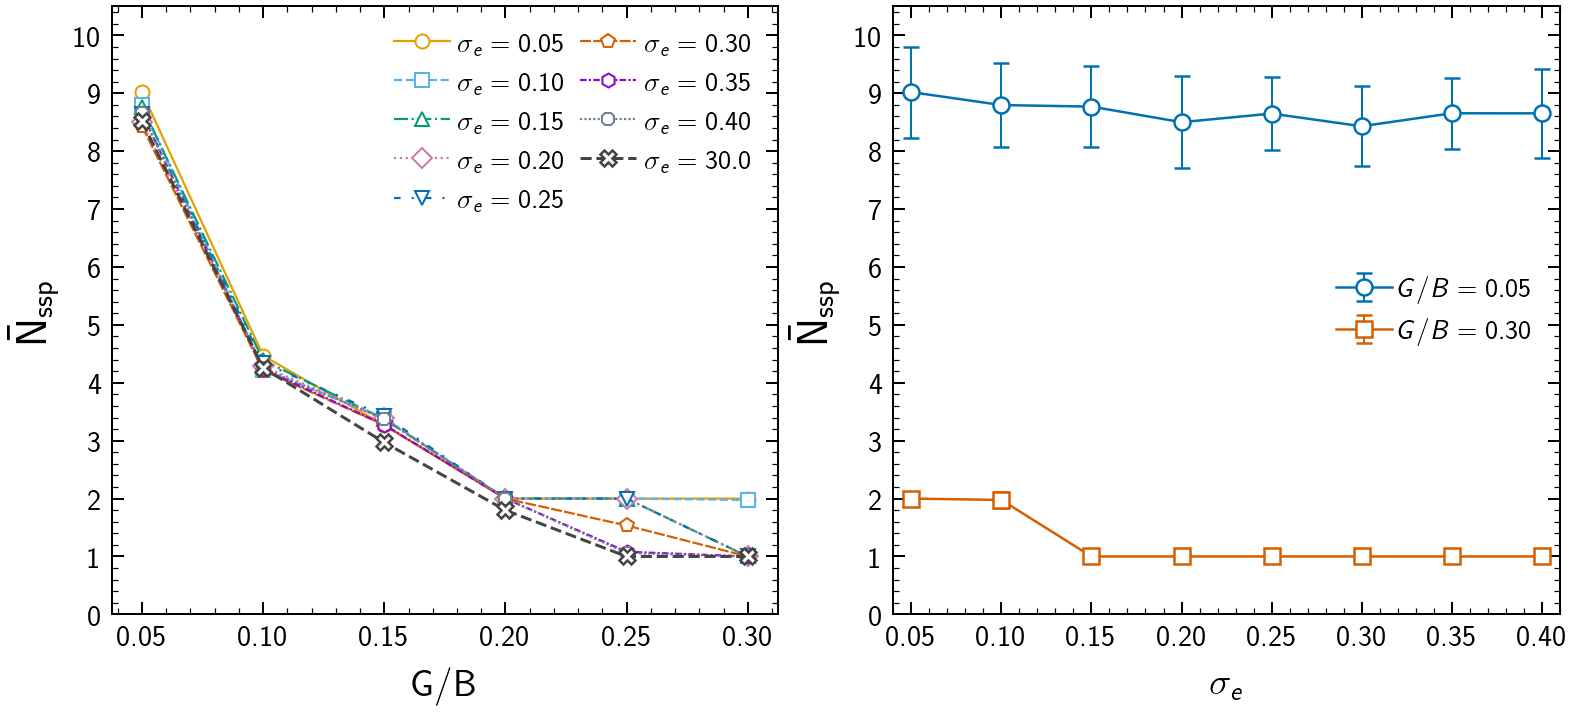

In [8]:
warnings.simplefilter(action='ignore', category=FutureWarning)

plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.latex.preamble': r'\usepackage{sfmath} \renewcommand{\familydefault}{\sfdefault} \normalfont',
})

data_folder_local = "DATA/local/"
data_folder_het = "code/DATA/sigma30/heterogeneous/" 

g_values = [5, 10, 15, 20, 25, 30] 
sigma_values = [5, 10, 15, 20, 25, 30, 35, 40] 

n_runs = 50
col_idx = 1 
window_frac = 0.05 

all_results = []

for g in g_values:
    for s_val in sigma_values:
        run_means = []
        p1 = os.path.join(data_folder_local, f"G{g}", f"sigma{s_val}")
        p2 = os.path.join(data_folder_local, f"G{g}", f"sigma{s_val/100:.2f}")
        path = p1 if os.path.exists(p1) else p2
        
        if os.path.exists(path):
            for run in range(1, n_runs + 1):
                fpath = os.path.join(path, f"evolution_global{run}.dat")
                try:
                    data = np.loadtxt(fpath, skiprows=1)
                    if data.ndim == 1: data = data.reshape(1, -1)
                    s_t = data[:, col_idx]
                    idx = int(len(s_t) * (1 - window_frac))
                    run_means.append(np.mean(s_t[idx:]))
                except: continue
        
        if run_means:
            all_results.append({
                'G_raw': g, 'G_norm': g * 0.01, 
                'Sigma_raw': s_val, 'Sigma_norm': s_val * 0.01,
                'Mean_S': np.mean(run_means), 'Std_S': np.std(run_means)
            })

het_list = []
for g in g_values:
    run_means_het = []
    path_het = os.path.join(data_folder_het, f"G{g}")
    if os.path.exists(path_het):
        for run in range(1, n_runs + 1):
            fpath = os.path.join(path_het, f"evolution_global{run}.dat")
            try:
                data = np.loadtxt(fpath, skiprows=1)
                s_t = data[:, col_idx]
                idx = int(len(s_t) * (1 - window_frac))
                run_means_het.append(np.mean(s_t[idx:]))
            except: continue
    if run_means_het:
        het_list.append({'G_norm': g * 0.01, 'Mean_S': np.mean(run_means_het)})

df = pd.DataFrame(all_results)
df_het = pd.DataFrame(het_list)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

cb_colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7', '#0072B2', '#D55E00', '#9400D3', '#708090']
markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '8']
linestyles = ['-', '--', '-.', ':', (0, (3, 5, 1, 5)), (0, (5, 1)), (0, (3, 1, 1, 1)), (0, (1, 1))]

if not df.empty:
    sigma_unique = sorted(df['Sigma_raw'].unique())
    for i, s in enumerate(sigma_unique):
        subset = df[df['Sigma_raw'] == s].sort_values('G_norm')
        color = cb_colors[i % len(cb_colors)]
        ax1.plot(subset['G_norm'], subset['Mean_S'], 
                 marker=markers[i % len(markers)], markersize=14, markeredgewidth=2.0,
                 markerfacecolor='white', markeredgecolor=color,
                 color=color, linestyle=linestyles[i % len(linestyles)],
                 lw=2.2, label=rf'$\sigma_e = {s/100:.2f}$', zorder=10)

if not df_het.empty:
    dark_grey = '#444444' 
    ax1.plot(df_het['G_norm'], df_het['Mean_S'], color=dark_grey, linestyle='--', linewidth=3,
             marker='X', markersize=16, markeredgecolor=dark_grey, 
             markerfacecolor='white', markeredgewidth=2.5,
             label=r'$\sigma_e = 30.0$', zorder=15)

g_targets = [5, 30]
styles_g = {
    5:  {'label': r'$G/B = 0.05$', 'color': '#0072B2', 'marker': 'o'},
    30: {'label': r'$G/B = 0.30$', 'color': '#D55E00', 'marker': 's'}
}

for g in g_targets:
    subset = df[df['G_raw'] == g].sort_values('Sigma_norm')
    ax2.errorbar(subset['Sigma_norm'], subset['Mean_S'], yerr=subset['Std_S'],
                 label=styles_g[g]['label'], color=styles_g[g]['color'],
                 marker=styles_g[g]['marker'], markersize=16, markerfacecolor='white',
                 markeredgewidth=2.5, lw=2.5, capsize=8, capthick=2, elinewidth=2,
                 linestyle='-', zorder=10)

for i, ax in enumerate([ax1, ax2]):
    ax.set_ylim(0, 10.5)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.tick_params(axis='both', which='major', direction='in', length=12, width=2, labelsize=30, top=True, right=True, pad=10)
    ax.tick_params(axis='both', which='minor', direction='in', length=6, width=1.2, top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    for spine in ax.spines.values(): spine.set_linewidth(2)
    
    if i == 0:
        ax.set_xlabel(r'$\mathsf{G/B}$', fontsize=38, labelpad=16)
        ax.set_ylabel(r'$\mathsf{\bar{N}_{ssp}}$', fontsize=44, labelpad=16)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.05))
        ax.legend(fontsize=28, frameon=False, loc='upper right', ncol=2, handletextpad=0.3, columnspacing=0.5)
    else:
        ax.set_xlabel(r'$\sigma_e$', fontsize=38, labelpad=16)
        ax.set_ylabel(r'$\mathsf{\bar{N}_{ssp}}$', fontsize=44, labelpad=16)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.05))
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter(r'$\mathsf{%.2f}$'))
        ax.set_xlim(0.04, 0.41)
        ax.legend(fontsize=28, frameon=False, loc='center right', handletextpad=0.2)

plt.tight_layout()
plt.savefig("richness.pdf", dpi=600, bbox_inches='tight')
plt.show()